# Курсовая работа: cравнительный анализ моделей глубокого обучения для задачи распознавания именованных сущностей

## 1. Постановка задачи

NER - это задача найти в тексте имена, организации, локации и другие сущности.

В работе сравниваются пять моделей на двух датасетах:
- модели: baseline `O`, BiLSTM, BiLSTM + CRF, BERT, DistilBERT
- датасеты: CoNLL-2003 (обучение и оценка), WNUT 17 (только проверка переноса)

Основная метрика - F1, дополнительно precision и recall. F1 выбрана потому, что в NER большая часть токенов имеет метку `O`, и обычная accuracy завышена: модель может почти всегда угадывать `O` и получать высокий процент, не находя при этом ни одной сущности. F1 считается только по самим сущностям и сразу учитывает и precision, и recall.

Исследовательский вопрос: как эти модели отличаются по качеству на CoNLL-2003 и как падает качество при переносе на WNUT 17.


## 2. Установка библиотек

Все версии зафиксированы в `requirements.txt`.


In [ ]:
%pip -q uninstall -y peft
%pip -q install --no-cache-dir -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 297.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 279.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 223.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 366.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 419.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 444.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 433.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2

## 3. Импорты и базовые настройки

Подключим основные библиотеки и зафиксируем seed для воспроизводимости.


In [ ]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["USE_TORCH"] = "1"

In [ ]:
import json
import random
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from seqeval.metrics import precision_score, recall_score, f1_score
from torchcrf import CRF
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

results = []
print("seed:", seed)
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())


seed: 42
torch: 2.10.0+cu128 | cuda: True


## 4. Загрузка CoNLL-2003 и WNUT 17

Оба датасета берём из HuggingFace `datasets`. CoNLL-2003 даёт train / validation / test, WNUT 17 используем только test.


In [ ]:
conll = load_dataset("conll2003", trust_remote_code=True)
wnut = load_dataset("wnut_17", trust_remote_code=True)

print("CoNLL-2003")
print(conll)
print("\nWNUT 17")
print(wnut)


def show_ner_examples(dataset, split_name, label_names, title, count=3):
    print(f"\n{title}, split={split_name}: первые {count} примера")
    for i in range(count):
        item = dataset[split_name][i]
        pairs = list(zip(item["tokens"], [label_names[t] for t in item["ner_tags"]]))
        print(f"\nПример {i}:", pairs)


conll_label_names = conll["train"].features["ner_tags"].feature.names
wnut_label_names = wnut["train"].features["ner_tags"].feature.names

show_ner_examples(conll, "train", conll_label_names, "CoNLL-2003")
show_ner_examples(wnut, "train", wnut_label_names, "WNUT 17")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/3394 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1009 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1287 [00:00<?, ? examples/s]

CoNLL-2003
DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

WNUT 17
DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 3394
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 1009
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 1287
    })
})

CoNLL-2003, split=train: первые 3 примера

Пример 0: [('EU', 'B-ORG'), ('rejects', 'O'), ('German', 'B-MISC'), ('call', 'O'), ('to', 'O'), ('boycott', 'O'), ('British', 'B-MISC'), ('lamb', 'O'), ('.', 'O')]

Пример 1: [('Peter', 'B-PER'), ('Blackburn', 'I-PER')]



### Что видно по загруженным данным

CoNLL-2003 - это новостные тексты. В первых примерах попадаются короткие предложения и заголовки: `EU rejects German call to boycott British lamb`, `BRUSSELS 1996-08-22`. Метки: `PER`, `ORG`, `LOC`, `MISC` и `O`.

WNUT 17 заметно шумнее и похож на соцсети: в первых примерах встречаются ники (`@paulwalk`), URL и хэштеги. Набор меток у него свой и отличается от CoNLL-2003 - конкретное сопоставление сделаем в следующем разделе.


### Проверка целостности данных

В датасетах HuggingFace для NER пропуски не предусмотрены: каждый пример обязан содержать непустой список токенов и соответствующий список меток той же длины. Но всё же проверим, так ли это


In [ ]:
for name, ds in [
    ("CoNLL-2003 train", conll["train"]),
    ("CoNLL-2003 validation", conll["validation"]),
    ("CoNLL-2003 test", conll["test"]),
    ("WNUT 17 train", wnut["train"]),
    ("WNUT 17 validation", wnut["validation"]),
    ("WNUT 17 test", wnut["test"]),
]:
    empty = sum(1 for x in ds if not x["tokens"])
    print(f"{name}: примеров без токенов = {empty}")


CoNLL-2003 train: примеров без токенов = 0
CoNLL-2003 validation: примеров без токенов = 0
CoNLL-2003 test: примеров без токенов = 0
WNUT 17 train: примеров без токенов = 0
WNUT 17 validation: примеров без токенов = 0
WNUT 17 test: примеров без токенов = 0


## 5. Подготовка меток и mappings

Готовим словари `label2id` и `id2label` для CoNLL-2003.

WNUT 17 использует другой набор типов, поэтому для оценки переноса нужно сопоставление. Делаем его осторожно: `person → PER`, `location → LOC`, `corporation` и `group → ORG`. Типы `creative-work` и `product` в CoNLL-2003 не имеют аналогов и переводятся в `O`. Это занижает recall на WNUT 17, но даёт честную in-domain интерпретацию ошибок: модель оценивается только по тем типам, на которые она была обучена.

Дальше посмотрим на распределение типов сущностей и длины предложений.


In [ ]:
label_names = conll_label_names
label2id = {label: i for i, label in enumerate(label_names)}
id2label = {i: label for label, i in label2id.items()}
num_labels = len(label_names)

wnut_type_map = {
    "person": "PER",
    "location": "LOC",
    "corporation": "ORG",
    "group": "ORG",
}


def wnut_tag_to_conll(tag):
    if tag == "O":
        return "O"
    prefix, name = tag.split("-", 1)
    mapped = wnut_type_map.get(name)
    return f"{prefix}-{mapped}" if mapped else "O"


wnut_to_conll_id = {}
mapping_rows = []
for wnut_id, wnut_tag in enumerate(wnut_label_names):
    conll_tag = wnut_tag_to_conll(wnut_tag)
    conll_id = label2id.get(conll_tag, label2id["O"])
    wnut_to_conll_id[wnut_id] = conll_id
    mapping_rows.append({
        "wnut_label": wnut_tag,
        "conll_label": id2label[conll_id],
    })

mapping_table = pd.DataFrame(mapping_rows)

print("Сопоставление WNUT 17 → CoNLL-2003:")
display(mapping_table)
print("\nlabel2id (CoNLL-2003):", label2id)


Сопоставление WNUT 17 → CoNLL-2003:


,wnut_label,conll_label
0,O,O
1,B-corporation,B-ORG
2,I-corporation,I-ORG
3,B-creative-work,O
4,I-creative-work,O
5,B-group,B-ORG
6,I-group,I-ORG
7,B-location,B-LOC
8,I-location,I-LOC
9,B-person,B-PER



label2id (CoNLL-2003): {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6, 'B-MISC': 7, 'I-MISC': 8}


Дисбаланс класса O:


,Всего токенов,Токенов O,"Доля O, %"
CoNLL-2003 train,203621,169578,83.28
WNUT 17 train,62730,59570,94.96



Количество токенов по типам сущностей:


,CoNLL-2003 train,WNUT 17 train
LOC,8297,0
MISC,4593,0
ORG,10025,0
PER,11128,0
corporation,0,267
creative-work,0,346
group,0,414
location,0,793
person,0,995
product,0,345


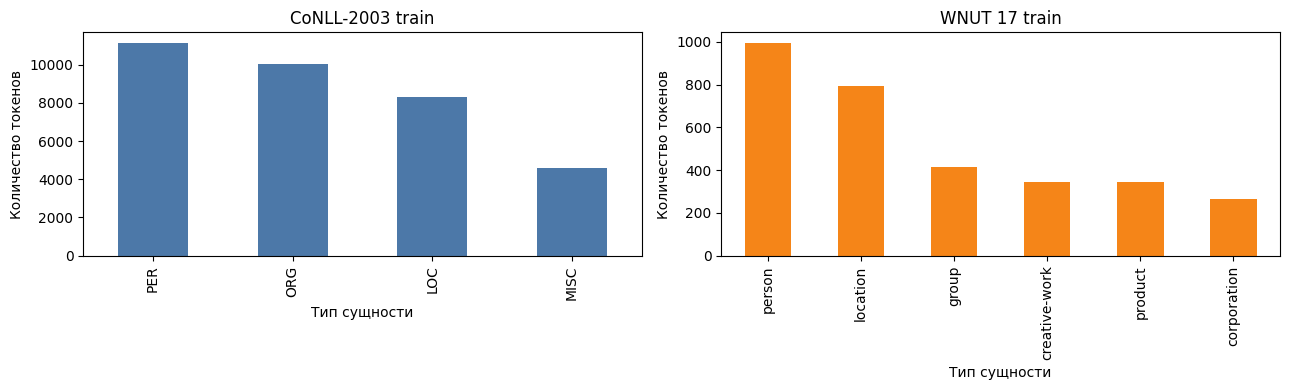

In [ ]:
def count_bio_labels(split, label_list):
    counter = Counter()
    for item in split:
        for tag_id in item["ner_tags"]:
            counter[label_list[int(tag_id)]] += 1
    return pd.Series(counter).sort_values(ascending=False)


def count_entity_types(split, label_list):
    counter = Counter()
    for item in split:
        for tag_id in item["ner_tags"]:
            tag = label_list[int(tag_id)]
            if tag == "O":
                continue
            counter[tag.split("-", 1)[1]] += 1
    return pd.Series(counter).sort_values(ascending=False)


# Доля O в обоих датасетах - иллюстрация дисбаланса
conll_all = count_bio_labels(conll["train"], label_names)
wnut_all = count_bio_labels(wnut["train"], wnut_label_names)
o_share = pd.DataFrame({
    "Всего токенов": [conll_all.sum(), wnut_all.sum()],
    "Токенов O": [conll_all.get("O", 0), wnut_all.get("O", 0)],
}, index=["CoNLL-2003 train", "WNUT 17 train"])
o_share["Доля O, %"] = (o_share["Токенов O"] / o_share["Всего токенов"] * 100).round(2)
print("Дисбаланс класса O:")
display(o_share)

# Распределение по типам сущностей (без O и без BIO-префикса)
conll_entities = count_entity_types(conll["train"], label_names)
wnut_entities = count_entity_types(wnut["train"], wnut_label_names)
entity_counts = pd.DataFrame({
    "CoNLL-2003 train": conll_entities,
    "WNUT 17 train": wnut_entities,
}).fillna(0).astype(int)

print("\nКоличество токенов по типам сущностей:")
display(entity_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
conll_entities.plot(kind="bar", ax=axes[0], color="#4C78A8", title="CoNLL-2003 train")
wnut_entities.plot(kind="bar", ax=axes[1], color="#F58518", title="WNUT 17 train")
for ax in axes:
    ax.set_xlabel("Тип сущности")
    ax.set_ylabel("Количество токенов")
plt.tight_layout()
plt.show()


Статистика длины предложений в токенах:


,dataset,mean,median,p95,max
0,CoNLL-2003 train,14.50,10.0,37.0,113
1,WNUT 17 train,18.48,18.0,30.0,41


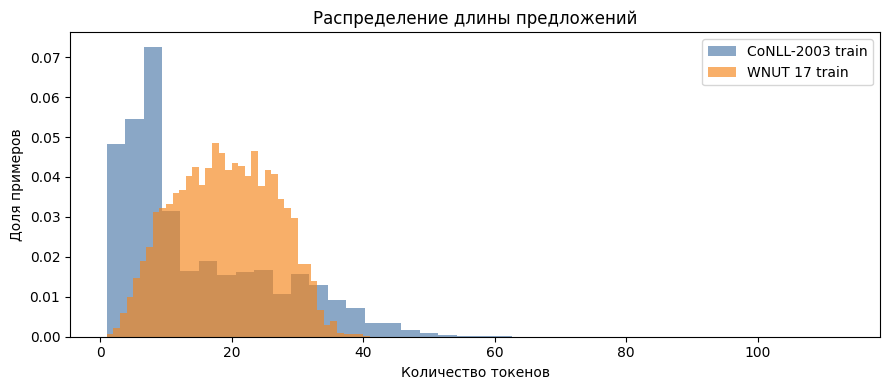

In [ ]:
conll_lengths = [len(item["tokens"]) for item in conll["train"]]
wnut_lengths = [len(item["tokens"]) for item in wnut["train"]]

length_stats = pd.DataFrame([
    {
        "dataset": name,
        "mean": np.mean(lengths),
        "median": np.median(lengths),
        "p95": np.percentile(lengths, 95),
        "max": np.max(lengths),
    }
    for name, lengths in [("CoNLL-2003 train", conll_lengths), ("WNUT 17 train", wnut_lengths)]
]).round(2)

print("Статистика длины предложений в токенах:")
display(length_stats)

plt.figure(figsize=(9, 4))
plt.hist(conll_lengths, bins=40, alpha=0.65, label="CoNLL-2003 train", color="#4C78A8", density=True)
plt.hist(wnut_lengths, bins=40, alpha=0.65, label="WNUT 17 train", color="#F58518", density=True)
plt.title("Распределение длины предложений")
plt.xlabel("Количество токенов")
plt.ylabel("Доля примеров")
plt.legend()
plt.tight_layout()
plt.show()


### Вывод по меткам и графикам

В обоих датасетах метка `O` занимает подавляющую долю всех токенов (см. таблицу выше). Это типичный для NER дисбаланс: token accuracy здесь не работает как метрика, поэтому дальше используется entity-level F1.

По длине предложений датасеты сопоставимы - медиана и p95 близки, абсолютное большинство примеров укладываются в десятки токенов. Это значит, что транформерам хватит небольшого `max_length`, а BiLSTM не упрётся в слишком длинные последовательности при padding.

Главное отличие WNUT 17 от CoNLL-2003 - стиль текста (шумные соцсети vs новости) и другой набор типов сущностей. Это и есть domain shift, качество переноса проверим в экспериментах.


## 6. Общие функции оценки через `seqeval`

Все модели оцениваются одним и тем же кодом. Это нужно, чтобы числа были сопоставимы.

Функции в этом блоке:
- переводят id меток обратно в BIO-строки;
- игнорируют padding и `-100` (метка-заглушка для специальных и subword-токенов);
- считают precision, recall и F1 через `seqeval`;
- добавляют результат в общую таблицу `results`.


In [ ]:
def ids_to_label_names(batch_ids, id2label, batch_mask=None):
    label_sequences = []
    for i, sentence_ids in enumerate(batch_ids):
        sentence_labels = []
        for j, label_id in enumerate(sentence_ids):
            if batch_mask is not None and not bool(batch_mask[i][j]):
                continue
            if int(label_id) == -100:
                continue
            sentence_labels.append(id2label[int(label_id)])
        label_sequences.append(sentence_labels)
    return label_sequences


def compute_ner_metrics(true_labels, pred_labels):
    return {
        "precision": precision_score(true_labels, pred_labels, zero_division=0),
        "recall": recall_score(true_labels, pred_labels, zero_division=0),
        "f1": f1_score(true_labels, pred_labels, zero_division=0),
    }


def add_result(model_name, dataset_name, metrics):
    global results
    row = {
        "model": model_name,
        "dataset": dataset_name,
        "precision": round(float(metrics["precision"]), 4),
        "recall": round(float(metrics["recall"]), 4),
        "f1": round(float(metrics["f1"]), 4),
    }
    results = [
        old_row for old_row in results
        if not (old_row["model"] == model_name and old_row["dataset"] == dataset_name)
    ]
    results.append(row)
    return row


def show_result(model_name, dataset_name, metrics):
    row = add_result(model_name, dataset_name, metrics)
    print(
        f"{model_name} на {dataset_name}: "
        f"precision={row['precision']}, "
        f"recall={row['recall']}, "
        f"f1={row['f1']}"
    )
    return row


## 7. Baseline `O`

Baseline предсказывает `O` для каждого токена. Сущности он не находит вообще, но угадывает все токены с меткой `O` - а их в датасете большинство.

Для него считаем два набора метрик:
- entity-level `precision`/`recall`/`f1` через `seqeval` - основная оценка;
- `token_accuracy` - диагностика, чтобы показать на конкретных числах, почему accuracy в NER обманчива.


In [ ]:
def token_accuracy_score(true_label_ids, pred_label_ids):
    total = 0
    correct = 0
    for true_sent, pred_sent in zip(true_label_ids, pred_label_ids):
        for t, p in zip(true_sent, pred_sent):
            if int(t) == -100:
                continue
            total += 1
            correct += int(int(t) == int(p))
    return correct / total if total > 0 else 0.0


def evaluate_o_baseline(split, dataset_name, label_mapping=None):
    true_ids, pred_ids = [], []
    for item in split:
        labels = item["ner_tags"]
        if label_mapping is not None:
            labels = [label_mapping[int(x)] for x in labels]
        labels = [int(x) for x in labels]
        true_ids.append(labels)
        pred_ids.append([label2id["O"]] * len(labels))

    true_labels = [[id2label[i] for i in sent] for sent in true_ids]
    pred_labels = [[id2label[i] for i in sent] for sent in pred_ids]

    metrics = compute_ner_metrics(true_labels, pred_labels)
    token_acc = token_accuracy_score(true_ids, pred_ids)
    row = show_result("O baseline", dataset_name, metrics)
    print(f"   token_accuracy={token_acc:.4f}")
    return {**row, "token_accuracy": round(float(token_acc), 4)}


baseline_conll_diagnostic = evaluate_o_baseline(conll["test"], "CoNLL-2003 test")
baseline_wnut_diagnostic = evaluate_o_baseline(
    wnut["test"], "WNUT 17 test", label_mapping=wnut_to_conll_id,
)

baseline_diagnostic_df = pd.DataFrame([baseline_conll_diagnostic, baseline_wnut_diagnostic])
baseline_conll_row = {k: v for k, v in baseline_conll_diagnostic.items() if k != "token_accuracy"}
baseline_wnut_row = {k: v for k, v in baseline_wnut_diagnostic.items() if k != "token_accuracy"}

print("\nBaseline: entity-level метрики + token accuracy")
display(baseline_diagnostic_df)


O baseline на CoNLL-2003 test: precision=0.0, recall=0.0, f1=0.0
   token_accuracy=0.8253
O baseline на WNUT 17 test: precision=0.0, recall=0.0, f1=0.0
   token_accuracy=0.9518

Baseline: entity-level метрики + token accuracy


,model,dataset,precision,recall,f1,token_accuracy
0,O baseline,CoNLL-2003 test,0.0,0.0,0.0,0.8253
1,O baseline,WNUT 17 test,0.0,0.0,0.0,0.9518


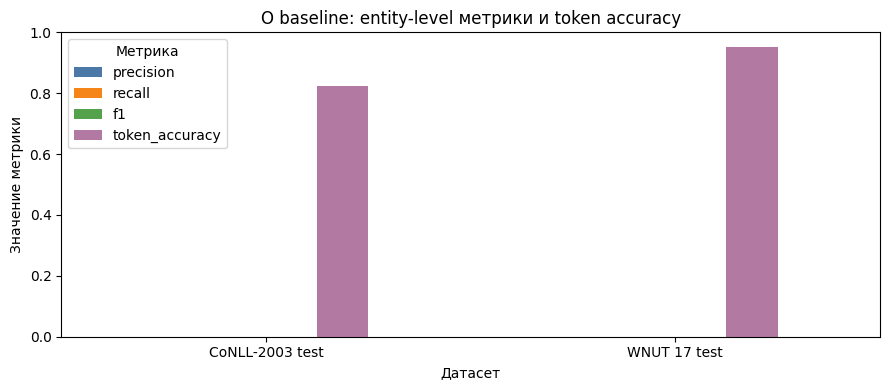

In [ ]:
baseline_plot_df = baseline_diagnostic_df.set_index("dataset")[["precision", "recall", "f1", "token_accuracy"]]

ax = baseline_plot_df.plot(
    kind="bar",
    figsize=(9, 4),
    color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"],
)
ax.set_title("O baseline: entity-level метрики и token accuracy")
ax.set_xlabel("Датасет")
ax.set_ylabel("Значение метрики")
ax.set_ylim(0, 1)
ax.legend(title="Метрика")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Вывод по baseline

Entity-level F1 равен нулю - baseline вообще не находит сущности. При этом token accuracy на CoNLL-2003 и WNUT 17 заметно выше нуля, потому что метка `O` в обоих датасетах самая частая.

На графике эта разница видна напрямую: голубые/оранжевые/зелёные полосы (precision, recall, F1) - нули, фиолетовая (token accuracy) - около уровня доли `O` в датасете. Это и есть подтверждение, почему в качестве основной метрики мы используем F1, а не accuracy: accuracy здесь высокая у модели, которая не решает задачу вообще.

Baseline даёт нижнюю точку отсчёта - любая обученная модель должна давать F1 выше нуля.


## 8. Fine-tuning BERT

Берём `bert-base-cased` и дообучаем на CoNLL-2003 для token classification.

BERT работает с subword-токенами (одно слово может распасться на несколько кусков), поэтому метки `ner_tags` нужно выровнять: первый subword слова получает метку слова, остальные subword'ы и спецтокены получают `-100` и игнорируются при подсчёте loss и метрик.

Обучение вынесено в отдельную ячейку. Если веса уже сохранены в Drive - они подгружаются, иначе запускается fine-tuning.


In [ ]:
bert_checkpoint = "bert-base-cased"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_checkpoint)


def align_labels_with_tokens(labels, word_ids):
    """Первый subword слова получает метку слова, остальные → -100."""
    aligned = []
    previous_word_id = None
    for word_id in word_ids:
        if word_id is None or word_id == previous_word_id:
            aligned.append(-100)
        else:
            aligned.append(int(labels[word_id]))
        previous_word_id = word_id
    return aligned


def tokenize_and_align(batch, tokenizer, label_mapping=None):
    tokenized = tokenizer(
        batch["tokens"],
        truncation=True,
        is_split_into_words=True,
    )
    aligned = []
    for i, labels in enumerate(batch["ner_tags"]):
        if label_mapping is not None:
            labels = [label_mapping[int(x)] for x in labels]
        word_ids = tokenized.word_ids(batch_index=i)
        aligned.append(align_labels_with_tokens(labels, word_ids))
    tokenized["labels"] = aligned
    return tokenized


tokenized_conll = conll.map(
    lambda batch: tokenize_and_align(batch, bert_tokenizer),
    batched=True,
)
tokenized_wnut_test = wnut["test"].map(
    lambda batch: tokenize_and_align(batch, bert_tokenizer, label_mapping=wnut_to_conll_id),
    batched=True,
)

print(tokenized_conll)
print(tokenized_wnut_test)


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Map:   0%|          | 0/1287 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3453
    })
})
Dataset({
    features: ['id', 'tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 1287
})


In [ ]:
bert_sample = tokenized_conll["train"][0]
bert_sample_tokens = bert_tokenizer.convert_ids_to_tokens(bert_sample["input_ids"])
bert_sample_labels = [
    "IGN" if label_id == -100 else id2label[int(label_id)]
    for label_id in bert_sample["labels"]
]

print("Исходные токены:", conll["train"][0]["tokens"])
print("\nВыравнивание BERT-токенов с метками:")
for tok, lbl in zip(bert_sample_tokens, bert_sample_labels):
    print(f"  {tok:<15} {lbl}")

print(f"\nДлины input_ids и labels: {len(bert_sample['input_ids'])} / {len(bert_sample['labels'])}")


Исходные токены: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']

Выравнивание BERT-токенов с метками:
  [CLS]           IGN
  EU              B-ORG
  rejects         O
  German          B-MISC
  call            O
  to              O
  boycott         O
  British         B-MISC
  la              O
  ##mb            IGN
  .               O
  [SEP]           IGN

Длины input_ids и labels: 12 / 12


### Настройки и обучение BERT

Готовим `TrainingArguments`, `Trainer` и функцию метрик. Настройки умеренные для Colab: 2 эпохи, batch size 8, `weight_decay=0.01`, learning rate `2e-5`, оценка на validation после каждой эпохи, сохранение лучшей модели по validation F1.

Веса сохраняются в Google Drive (`drive/MyDrive/ner_course_project/models/...`). Это позволяет не переобучать модель после перезапуска runtime - следующая ячейка либо загружает сохранённую модель, либо запускает обучение, если её ещё нет.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

drive_project_dir = Path("/content/drive/MyDrive/ner_course_project")
drive_project_dir.mkdir(parents=True, exist_ok=True)

bert_output_dir = drive_project_dir / "training_outputs" / "bert-base-cased-conll2003-ner"
bert_model_dir = drive_project_dir / "models" / "bert-base-cased-conll2003-ner"
bert_output_dir.mkdir(parents=True, exist_ok=True)
bert_model_dir.mkdir(parents=True, exist_ok=True)


def compute_transformer_metrics(eval_pred):
    predictions = eval_pred.predictions if hasattr(eval_pred, "predictions") else eval_pred[0]
    labels = eval_pred.label_ids if hasattr(eval_pred, "label_ids") else eval_pred[1]
    predicted_ids = np.argmax(predictions, axis=-1)

    true_labels, pred_labels = [], []
    for pred_sent, label_sent in zip(predicted_ids, labels):
        cur_true, cur_pred = [], []
        for pred_id, label_id in zip(pred_sent, label_sent):
            if int(label_id) == -100:
                continue
            cur_true.append(id2label[int(label_id)])
            cur_pred.append(id2label[int(pred_id)])
        true_labels.append(cur_true)
        pred_labels.append(cur_pred)
    return compute_ner_metrics(true_labels, pred_labels)


def make_training_arguments(output_dir):
    training_kwargs = dict(
        output_dir=str(output_dir),
        save_strategy="epoch",
        save_total_limit=2,
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=2,
        weight_decay=0.01,
        logging_strategy="epoch",
        report_to="none",
        seed=seed,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
    )
    # eval_strategy переименован в новых версиях transformers; поддерживаем оба варианта
    try:
        return TrainingArguments(eval_strategy="epoch", **training_kwargs)
    except TypeError:
        return TrainingArguments(evaluation_strategy="epoch", **training_kwargs)


def build_bert_trainer(model=None):
    if model is None:
        model = AutoModelForTokenClassification.from_pretrained(
            bert_checkpoint,
            num_labels=num_labels,
            id2label=id2label,
            label2id=label2id,
        )
    return Trainer(
        model=model,
        args=make_training_arguments(bert_output_dir),
        train_dataset=tokenized_conll["train"],
        eval_dataset=tokenized_conll["validation"],
        data_collator=DataCollatorForTokenClassification(tokenizer=bert_tokenizer),
        tokenizer=bert_tokenizer,
        compute_metrics=compute_transformer_metrics,
    )


print("Папка проекта на Drive:", drive_project_dir)
print("BERT trainer готов к созданию. Обучение или загрузка - в следующей ячейке.")


Mounted at /content/drive
Папка проекта на Drive: /content/drive/MyDrive/ner_course_project
BERT trainer готов к созданию. Обучение или загрузка — в следующей ячейке.


In [ ]:
# Если модель уже сохранена в Drive - загружаем. Иначе обучаем и сохраняем.
if (bert_model_dir / "config.json").exists():
    loaded_bert_model = AutoModelForTokenClassification.from_pretrained(str(bert_model_dir))
    bert_trainer = build_bert_trainer(model=loaded_bert_model)
    print("Сохранённая BERT-модель загружена из:", bert_model_dir)
else:
    print("Сохранённая модель не найдена. Запускаю обучение BERT.")
    bert_trainer = build_bert_trainer()
    bert_train_start = time.perf_counter()
    bert_train_result = bert_trainer.train()
    bert_train_wall_time = time.perf_counter() - bert_train_start

    bert_history_path = bert_model_dir / "trainer_history.json"
    with bert_history_path.open("w", encoding="utf-8") as f:
        json.dump(bert_trainer.state.log_history, f, ensure_ascii=False, indent=2)


    bert_trainer.save_model(str(bert_model_dir))
    bert_tokenizer.save_pretrained(str(bert_model_dir))

    label_mapping_path = bert_model_dir / "label_mappings.json"
    with label_mapping_path.open("w", encoding="utf-8") as f:
        json.dump(
            {
                "label_names": label_names,
                "label2id": label2id,
                "id2label": {str(k): v for k, v in id2label.items()},
                "wnut_type_map": wnut_type_map,
            },
            f,
            ensure_ascii=False,
            indent=2,
        )
    print("Модель, tokenizer и label mappings сохранены в:", bert_model_dir)
    print("Время обучения BERT, секунд:", round(bert_train_wall_time, 2))

print("\nФайлы в папке модели:")
for file_path in sorted(bert_model_dir.iterdir()):
    print(" ", file_path.name)


Сохранённая модель не найдена. Запускаю обучение BERT.


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.096100,0.040806,0.934874,0.939751,0.937306
2,0.023900,0.040354,0.944156,0.950353,0.947245


Модель, tokenizer и label mappings сохранены в: /content/drive/MyDrive/ner_course_project/models/bert-base-cased-conll2003-ner
Время обучения BERT, секунд: 496.83

Файлы в папке модели:
  config.json
  label_mappings.json
  model.safetensors
  special_tokens_map.json
  tokenizer.json
  tokenizer_config.json
  trainer_history.json
  training_args.bin
  vocab.txt


### Оценка BERT

Оцениваем BERT на CoNLL-2003 test (in-domain) и WNUT 17 test (out-of-domain).


In [ ]:
bert_conll_eval = bert_trainer.evaluate(tokenized_conll["test"])
bert_conll_metrics = {
    "precision": bert_conll_eval["eval_precision"],
    "recall": bert_conll_eval["eval_recall"],
    "f1": bert_conll_eval["eval_f1"],
}
bert_conll_row = show_result("BERT", "CoNLL-2003 test", bert_conll_metrics)

bert_wnut_predictions = bert_trainer.predict(tokenized_wnut_test)
bert_wnut_metrics = compute_transformer_metrics(bert_wnut_predictions)
bert_wnut_row = show_result("BERT", "WNUT 17 test", bert_wnut_metrics)

bert_results_df = pd.DataFrame([bert_conll_row, bert_wnut_row])
display(bert_results_df)


BERT на CoNLL-2003 test: precision=0.9018, recall=0.9189, f1=0.9103
BERT на WNUT 17 test: precision=0.3333, recall=0.4864, f1=0.3956


,model,dataset,precision,recall,f1
0,BERT,CoNLL-2003 test,0.9018,0.9189,0.9103
1,BERT,WNUT 17 test,0.3333,0.4864,0.3956


### Вывод после BERT

На CoNLL-2003 BERT даёт высокий F1 (см. таблицу выше) - заметно выше нулевого baseline. Это ожидаемо: модель предобучена на большом корпусе и быстро адаптируется к разметке за 2 эпохи fine-tuning.

На WNUT 17 F1 падает в 2-3 раза. У этого падения две причины:
- domain shift - WNUT 17 это шумные соцсети, а BERT обучался и дообучался на новостях;
- наш mapping меток: типы `creative-work` и `product` нами переведены в `O`, поэтому корректные предсказания BERT на этих сущностях штрафуются как ошибки. Это занижает recall.

Цифры на WNUT 17 - это «нижняя граница» переноса без дообучения.


## 9. BiLSTM

Теперь обучим BiLSTM-модель. Архитектура простая: `Embedding -> BiLSTM -> Linear`. Сначала готовим словарь и числовое кодирование предложений, потом описываем модель, обучение и оценку.


### Словарь для BiLSTM и BiLSTM + CRF

В отличие от BERT, BiLSTM использует обычный словарь слов. Строим его **только** по CoNLL-2003 `train` - это важно, чтобы не подглядывать в validation, test и WNUT 17. Незнакомые слова в остальных splits будут заменены на `<UNK>`.


In [ ]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
PAD_ID = 0
UNK_ID = 1

token_counter = Counter()
for item in conll["train"]:
    token_counter.update(item["tokens"])

vocab = {PAD_TOKEN: PAD_ID, UNK_TOKEN: UNK_ID}
for token, _ in token_counter.most_common():
    vocab[token] = len(vocab)


def encode_tokens(tokens):
    return [vocab.get(token, UNK_ID) for token in tokens]


def prepare_sequence_data(split, label_mapping=None):
    prepared = []
    for item in split:
        labels = item["ner_tags"]
        if label_mapping is not None:
            labels = [label_mapping[int(label_id)] for label_id in labels]

        prepared.append({
            "tokens": item["tokens"],
            "input_ids": encode_tokens(item["tokens"]),
            "labels": [int(label_id) for label_id in labels],
        })
    return prepared


bilstm_train_data = prepare_sequence_data(conll["train"])
bilstm_valid_data = prepare_sequence_data(conll["validation"])
bilstm_conll_test_data = prepare_sequence_data(conll["test"])
bilstm_wnut_test_data = prepare_sequence_data(wnut["test"], label_mapping=wnut_to_conll_id)

print("Размер словаря:", len(vocab))
print("Первые элементы словаря:", list(vocab.items())[:10])
print("Пример encoded input_ids:", bilstm_train_data[0]["input_ids"])
print("Пример labels:", bilstm_train_data[0]["labels"])


Размер словаря: 23625
Первые элементы словаря: [('<PAD>', 0), ('<UNK>', 1), ('.', 2), (',', 3), ('the', 4), ('of', 5), ('in', 6), ('to', 7), ('a', 8), ('(', 9)]
Пример encoded input_ids: [958, 11984, 234, 763, 7, 4148, 210, 6183, 2]
Пример labels: [3, 0, 7, 0, 0, 0, 7, 0, 0]


,dataset,sentences,tokens,unknown_tokens,unknown_rate
0,CoNLL train,14041,203621,0,0.0000
1,CoNLL validation,3250,51362,4293,0.0836
2,CoNLL test,3453,46435,5656,0.1218
3,WNUT test,1287,23394,5737,0.2452


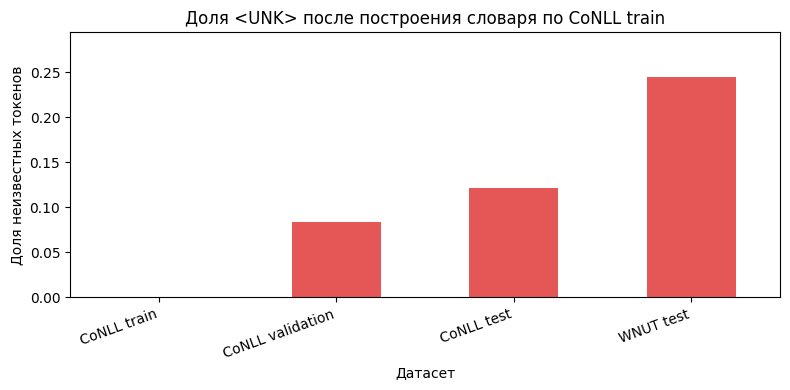

In [ ]:
def sequence_data_stats(name, data):
    token_count = sum(len(item["input_ids"]) for item in data)
    unknown_count = sum(
        token_id == UNK_ID
        for item in data
        for token_id in item["input_ids"]
    )
    return {
        "dataset": name,
        "sentences": len(data),
        "tokens": token_count,
        "unknown_tokens": unknown_count,
        "unknown_rate": round(unknown_count / token_count, 4),
    }


sequence_data_summary = pd.DataFrame([
    sequence_data_stats("CoNLL train", bilstm_train_data),
    sequence_data_stats("CoNLL validation", bilstm_valid_data),
    sequence_data_stats("CoNLL test", bilstm_conll_test_data),
    sequence_data_stats("WNUT test", bilstm_wnut_test_data),
])

display(sequence_data_summary)

ax = sequence_data_summary.set_index("dataset")["unknown_rate"].plot(
    kind="bar",
    figsize=(8, 4),
    color="#E45756",
)
ax.set_title("Доля <UNK> после построения словаря по CoNLL train")
ax.set_xlabel("Датасет")
ax.set_ylabel("Доля неизвестных токенов")
ax.set_ylim(0, max(0.01, sequence_data_summary["unknown_rate"].max() * 1.2))
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


### Dataset и DataLoader для BiLSTM

Делаем простой `Dataset` и `collate_fn`. Предложения в batch'е дополняются до одной длины: токены - `<PAD>`, метки - `-100` (чтобы padding-позиции игнорировались в loss и метриках).


In [ ]:
class NerSequenceDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        item = self.data[index]
        return {
            "input_ids": torch.tensor(item["input_ids"], dtype=torch.long),
            "labels": torch.tensor(item["labels"], dtype=torch.long),
        }


def collate_ner_batch(batch):
    input_ids = [item["input_ids"] for item in batch]
    labels = [item["labels"] for item in batch]

    padded_input_ids = pad_sequence(input_ids, batch_first=True, padding_value=PAD_ID)
    padded_labels = pad_sequence(labels, batch_first=True, padding_value=-100)
    attention_mask = padded_input_ids.ne(PAD_ID)

    return {
        "input_ids": padded_input_ids,
        "labels": padded_labels,
        "attention_mask": attention_mask,
    }


bilstm_batch_size = 64

bilstm_train_loader = DataLoader(
    NerSequenceDataset(bilstm_train_data),
    batch_size=bilstm_batch_size,
    shuffle=True,
    collate_fn=collate_ner_batch,
)
bilstm_valid_loader = DataLoader(
    NerSequenceDataset(bilstm_valid_data),
    batch_size=bilstm_batch_size,
    shuffle=False,
    collate_fn=collate_ner_batch,
)
bilstm_conll_test_loader = DataLoader(
    NerSequenceDataset(bilstm_conll_test_data),
    batch_size=bilstm_batch_size,
    shuffle=False,
    collate_fn=collate_ner_batch,
)
bilstm_wnut_test_loader = DataLoader(
    NerSequenceDataset(bilstm_wnut_test_data),
    batch_size=bilstm_batch_size,
    shuffle=False,
    collate_fn=collate_ner_batch,
)

first_batch = next(iter(bilstm_train_loader))
print("input_ids shape:", first_batch["input_ids"].shape)
print("labels shape:", first_batch["labels"].shape)
print("attention_mask shape:", first_batch["attention_mask"].shape)

input_ids shape: torch.Size([64, 51])
labels shape: torch.Size([64, 51])
attention_mask shape: torch.Size([64, 51])


### Модель BiLSTM

BiLSTM читает последовательность токенов в двух направлениях. После этого линейный слой отдельно для каждого токена предсказывает одну из BIO-меток CoNLL-2003.

In [ ]:
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_labels, pad_id, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids):
        embeddings = self.embedding(input_ids)
        lstm_output, _ = self.lstm(embeddings)
        lstm_output = self.dropout(lstm_output)
        logits = self.classifier(lstm_output)
        return logits


bilstm_embedding_dim = 100
bilstm_hidden_dim = 128
bilstm_model_name = "bilstm-conll2003-ner"

if "drive_project_dir" not in globals():
    # Если BERT-ячейка с Drive не запускалась в этой сессии
    from google.colab import drive
    drive.mount("/content/drive")
    drive_project_dir = Path("/content/drive/MyDrive/ner_course_project")
    drive_project_dir.mkdir(parents=True, exist_ok=True)

bilstm_model_dir = drive_project_dir / "models" / bilstm_model_name
bilstm_model_path = bilstm_model_dir / "bilstm_model.pt"
bilstm_model_dir.mkdir(parents=True, exist_ok=True)

bilstm_model = BiLSTMTagger(
    vocab_size=len(vocab),
    embedding_dim=bilstm_embedding_dim,
    hidden_dim=bilstm_hidden_dim,
    num_labels=num_labels,
    pad_id=PAD_ID,
).to(device)

print(bilstm_model)
print("Папка для сохранения BiLSTM:", bilstm_model_dir)


BiLSTMTagger(
  (embedding): Embedding(23625, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=9, bias=True)
)
Папка для сохранения BiLSTM: /content/drive/MyDrive/ner_course_project/models/bilstm-conll2003-ner


### Функции обучения и оценки BiLSTM

Для обучения используется `CrossEntropyLoss`. Padding-позиции не участвуют в loss, потому что для них в метках стоит `-100`. Метрики считаются теми же функциями `seqeval`, что и для baseline и BERT.

In [ ]:
def evaluate_bilstm_model(model, data_loader):
    model.eval()
    all_true_ids = []
    all_pred_ids = []
    all_masks = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            logits = model(input_ids)
            predictions = logits.argmax(dim=-1)

            all_true_ids.extend(labels.cpu().tolist())
            all_pred_ids.extend(predictions.cpu().tolist())
            all_masks.extend(attention_mask.cpu().tolist())

    true_labels = ids_to_label_names(all_true_ids, id2label, all_masks)
    pred_labels = ids_to_label_names(all_pred_ids, id2label, all_masks)
    return compute_ner_metrics(true_labels, pred_labels)


def train_bilstm_model(model, train_loader, valid_loader, epochs=5, learning_rate=1e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

    best_f1 = -1.0
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        batch_count = 0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            logits = model(input_ids)
            loss = loss_fn(logits.view(-1, num_labels), labels.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += float(loss.item())
            batch_count += 1

        valid_metrics = evaluate_bilstm_model(model, valid_loader)
        avg_loss = total_loss / max(batch_count, 1)
        history.append({
            "epoch": epoch,
            "train_loss": round(avg_loss, 4),
            "valid_precision": round(float(valid_metrics["precision"]), 4),
            "valid_recall": round(float(valid_metrics["recall"]), 4),
            "valid_f1": round(float(valid_metrics["f1"]), 4),
        })

        print(
            f"epoch {epoch}: "
            f"loss={avg_loss:.4f}, "
            f"valid_precision={valid_metrics['precision']:.4f}, "
            f"valid_recall={valid_metrics['recall']:.4f}, "
            f"valid_f1={valid_metrics['f1']:.4f}"
        )

        if valid_metrics["f1"] > best_f1:
            best_f1 = valid_metrics["f1"]
            best_state = {
                name: parameter.detach().cpu().clone()
                for name, parameter in model.state_dict().items()
            }

    if best_state is not None:
        model.load_state_dict(best_state)

    return pd.DataFrame(history)

### Обучение BiLSTM

BiLSTM обучается на CoNLL-2003 train, после каждой эпохи качество проверяется на validation. По итогу в модель загружается лучшая по validation F1 версия, веса сохраняются в Drive.


epoch 1: loss=0.7039, valid_precision=0.5206, valid_recall=0.2129, valid_f1=0.3022
epoch 2: loss=0.3773, valid_precision=0.6118, valid_recall=0.4968, valid_f1=0.5483
epoch 3: loss=0.2426, valid_precision=0.7003, valid_recall=0.5820, valid_f1=0.6357
epoch 4: loss=0.1675, valid_precision=0.7295, valid_recall=0.6444, valid_f1=0.6843
epoch 5: loss=0.1185, valid_precision=0.7366, valid_recall=0.6898, valid_f1=0.7124
BiLSTM сохранена в: /content/drive/MyDrive/ner_course_project/models/bilstm-conll2003-ner/bilstm_model.pt


,epoch,train_loss,valid_precision,valid_recall,valid_f1
0,1,0.7039,0.5206,0.2129,0.3022
1,2,0.3773,0.6118,0.4968,0.5483
2,3,0.2426,0.7003,0.5820,0.6357
3,4,0.1675,0.7295,0.6444,0.6843
4,5,0.1185,0.7366,0.6898,0.7124


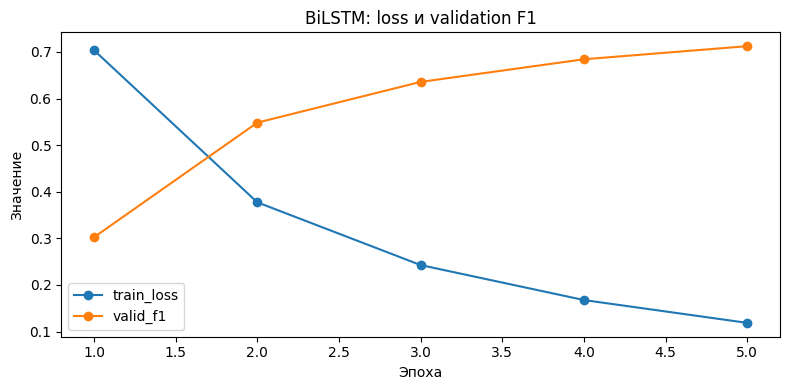

In [ ]:
def save_bilstm_checkpoint(model, history_df, path):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "vocab": vocab,
        "label2id": label2id,
        "id2label": id2label,
        "model_params": {
            "vocab_size": len(vocab),
            "embedding_dim": bilstm_embedding_dim,
            "hidden_dim": bilstm_hidden_dim,
            "num_labels": num_labels,
            "pad_id": PAD_ID,
        },
        "history": history_df.to_dict("records"),
    }
    torch.save(checkpoint, path)


if bilstm_model_path.exists():
    bilstm_checkpoint = torch.load(bilstm_model_path, map_location=device)
    bilstm_model.load_state_dict(bilstm_checkpoint["model_state_dict"])
    bilstm_history_df = pd.DataFrame(bilstm_checkpoint["history"])
    print("BiLSTM загружена из:", bilstm_model_path)
else:
    bilstm_history_df = train_bilstm_model(
        bilstm_model,
        bilstm_train_loader,
        bilstm_valid_loader,
        epochs=5,
        learning_rate=1e-3,
    )
    save_bilstm_checkpoint(bilstm_model, bilstm_history_df, bilstm_model_path)
    print("BiLSTM сохранена в:", bilstm_model_path)

display(bilstm_history_df)

ax = bilstm_history_df.plot(
    x="epoch",
    y=["train_loss", "valid_f1"],
    marker="o",
    figsize=(8, 4),
)
ax.set_title("BiLSTM: loss и validation F1")
ax.set_xlabel("Эпоха")
ax.set_ylabel("Значение")
plt.tight_layout()
plt.show()


### Оценка BiLSTM

Считаем precision, recall и F1 на CoNLL-2003 test и WNUT 17 test.


In [ ]:
bilstm_conll_metrics = evaluate_bilstm_model(bilstm_model, bilstm_conll_test_loader)
bilstm_conll_row = show_result("BiLSTM", "CoNLL-2003 test", bilstm_conll_metrics)

bilstm_wnut_metrics = evaluate_bilstm_model(bilstm_model, bilstm_wnut_test_loader)
bilstm_wnut_row = show_result("BiLSTM", "WNUT 17 test", bilstm_wnut_metrics)

bilstm_results_df = pd.DataFrame([bilstm_conll_row, bilstm_wnut_row])
display(bilstm_results_df)


BiLSTM на CoNLL-2003 test: precision=0.6638, recall=0.6153, f1=0.6386
BiLSTM на WNUT 17 test: precision=0.0844, recall=0.0901, f1=0.0872


,model,dataset,precision,recall,f1
0,BiLSTM,CoNLL-2003 test,0.6638,0.6153,0.6386
1,BiLSTM,WNUT 17 test,0.0844,0.0901,0.0872


### Вывод после BiLSTM

На CoNLL-2003 test BiLSTM даёт F1 заметно выше нуля - модель действительно научилась находить сущности. Но качество ниже BERT: BiLSTM учится с нуля и не имеет предобученных представлений языка.

На WNUT 17 test качество падает гораздо сильнее, чем у BERT. Основной просадке отвечает recall: модель пропускает сущности. У этого есть прямое объяснение в наших же данных - график `<UNK>` в секции 9: словарь построен по новостям, и в твитах большая доля токенов оказывается неизвестной. Эмбеддинг `<UNK>` несёт мало информации, поэтому модель не «узнаёт» имена и организации.

**Проверка на переобучение.** На графике `BiLSTM: loss и validation F1` выше видно, что train_loss монотонно снижается, а validation F1 монотонно растёт от эпохи к эпохе. Расхождения «loss падает, а valid F1 начинает падать» нет - переобучения за 5 эпох не наблюдается.


## 10. BiLSTM + CRF

Берём тот же BiLSTM-encoder и заменяем последний линейный слой → softmax на CRF-слой. Дальше всё то же: словарь, данные, оптимизация - отличается только выход.

CRF учитывает запрещённые переходы в BIO-разметке (например, после `O` не может идти `I-PER` - `I-` бывает только после `B-` того же типа). Идея: должна вырасти именно структурная согласованность предсказаний, а не общее «угадывание».


In [ ]:
bilstm_crf_model_name = "bilstm-crf-conll2003-ner"
bilstm_crf_model_dir = drive_project_dir / "models" / bilstm_crf_model_name
bilstm_crf_model_path = bilstm_crf_model_dir / "bilstm_crf_model.pt"
bilstm_crf_model_dir.mkdir(parents=True, exist_ok=True)

print("Папка для сохранения BiLSTM + CRF:", bilstm_crf_model_dir)

Папка для сохранения BiLSTM + CRF: /content/drive/MyDrive/ner_course_project/models/bilstm-crf-conll2003-ner


### Модель BiLSTM + CRF

Архитектура почти такая же, как у обычной BiLSTM: `Embedding -> BiLSTM -> Linear`, но выходы линейного слоя передаются в CRF. Во время обучения CRF считает отрицательный log-likelihood, а во время оценки декодирует лучшую последовательность меток.

In [ ]:
class BiLSTMCRFTagger(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_labels, pad_id, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)
        self.crf = CRF(num_labels, batch_first=True)

    def forward(self, input_ids):
        embeddings = self.embedding(input_ids)
        lstm_output, _ = self.lstm(embeddings)
        lstm_output = self.dropout(lstm_output)
        emissions = self.classifier(lstm_output)
        return emissions

    def loss(self, input_ids, labels, mask):
        emissions = self.forward(input_ids)
        safe_labels = labels.masked_fill(labels.eq(-100), label2id["O"])
        log_likelihood = self.crf(emissions, safe_labels, mask=mask.bool(), reduction="mean")
        return -log_likelihood

    def decode(self, input_ids, mask):
        emissions = self.forward(input_ids)
        return self.crf.decode(emissions, mask=mask.bool())


bilstm_crf_model = BiLSTMCRFTagger(
    vocab_size=len(vocab),
    embedding_dim=bilstm_embedding_dim,
    hidden_dim=bilstm_hidden_dim,
    num_labels=num_labels,
    pad_id=PAD_ID,
).to(device)

print(bilstm_crf_model)


BiLSTMCRFTagger(
  (embedding): Embedding(23625, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=9, bias=True)
  (crf): CRF(num_tags=9)
)


### Функции обучения и оценки BiLSTM + CRF

Оценка остается такой же через `seqeval`, но предсказания получаются через CRF decode. Для честного сравнения используются те же train, validation, test splits и те же размеры embedding/hidden, что у обычной BiLSTM.

In [ ]:
def evaluate_bilstm_crf_model(model, data_loader):
    model.eval()
    true_labels = []
    pred_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            decoded_batch = model.decode(input_ids, attention_mask)

            for decoded_labels, true_ids, mask in zip(
                decoded_batch,
                labels.cpu().tolist(),
                attention_mask.cpu().tolist(),
            ):
                current_true = []
                current_pred = []
                pred_index = 0

                for true_id, is_real_token in zip(true_ids, mask):
                    if not bool(is_real_token) or int(true_id) == -100:
                        continue
                    current_true.append(id2label[int(true_id)])
                    current_pred.append(id2label[int(decoded_labels[pred_index])])
                    pred_index += 1

                true_labels.append(current_true)
                pred_labels.append(current_pred)

    return compute_ner_metrics(true_labels, pred_labels)


def train_bilstm_crf_model(model, train_loader, valid_loader, epochs=5, learning_rate=1e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    best_f1 = -1.0
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        batch_count = 0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            optimizer.zero_grad()
            loss = model.loss(input_ids, labels, attention_mask)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += float(loss.item())
            batch_count += 1

        valid_metrics = evaluate_bilstm_crf_model(model, valid_loader)
        avg_loss = total_loss / max(batch_count, 1)
        history.append({
            "epoch": epoch,
            "train_loss": round(avg_loss, 4),
            "valid_precision": round(float(valid_metrics["precision"]), 4),
            "valid_recall": round(float(valid_metrics["recall"]), 4),
            "valid_f1": round(float(valid_metrics["f1"]), 4),
        })

        print(
            f"epoch {epoch}: "
            f"loss={avg_loss:.4f}, "
            f"valid_precision={valid_metrics['precision']:.4f}, "
            f"valid_recall={valid_metrics['recall']:.4f}, "
            f"valid_f1={valid_metrics['f1']:.4f}"
        )

        if valid_metrics["f1"] > best_f1:
            best_f1 = valid_metrics["f1"]
            best_state = {
                name: parameter.detach().cpu().clone()
                for name, parameter in model.state_dict().items()
            }

    if best_state is not None:
        model.load_state_dict(best_state)

    return pd.DataFrame(history)

### Обучение BiLSTM + CRF

BiLSTM + CRF обучается аналогично обычной BiLSTM. После каждой эпохи проверяется validation F1, лучшая по этой метрике версия сохраняется в Drive.


epoch 1: loss=9.3525, valid_precision=0.7232, valid_recall=0.2620, valid_f1=0.3847
epoch 2: loss=4.4540, valid_precision=0.7604, valid_recall=0.5042, valid_f1=0.6064
epoch 3: loss=2.8636, valid_precision=0.7840, valid_recall=0.5937, valid_f1=0.6757
epoch 4: loss=1.9281, valid_precision=0.8254, valid_recall=0.6429, valid_f1=0.7228
epoch 5: loss=1.3014, valid_precision=0.8134, valid_recall=0.6984, valid_f1=0.7515
BiLSTM + CRF сохранена в: /content/drive/MyDrive/ner_course_project/models/bilstm-crf-conll2003-ner/bilstm_crf_model.pt


,epoch,train_loss,valid_precision,valid_recall,valid_f1
0,1,9.3525,0.7232,0.2620,0.3847
1,2,4.4540,0.7604,0.5042,0.6064
2,3,2.8636,0.7840,0.5937,0.6757
3,4,1.9281,0.8254,0.6429,0.7228
4,5,1.3014,0.8134,0.6984,0.7515


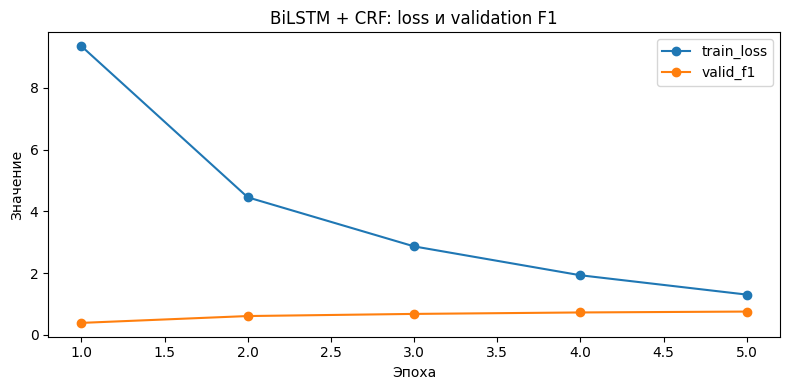

In [ ]:
def save_bilstm_crf_checkpoint(model, history_df, path):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "vocab": vocab,
        "label2id": label2id,
        "id2label": id2label,
        "model_params": {
            "vocab_size": len(vocab),
            "embedding_dim": bilstm_embedding_dim,
            "hidden_dim": bilstm_hidden_dim,
            "num_labels": num_labels,
            "pad_id": PAD_ID,
        },
        "history": history_df.to_dict("records"),
    }
    torch.save(checkpoint, path)


if bilstm_crf_model_path.exists():
    bilstm_crf_checkpoint = torch.load(bilstm_crf_model_path, map_location=device)
    bilstm_crf_model.load_state_dict(bilstm_crf_checkpoint["model_state_dict"])
    bilstm_crf_history_df = pd.DataFrame(bilstm_crf_checkpoint["history"])
    print("BiLSTM + CRF загружена из:", bilstm_crf_model_path)
else:
    bilstm_crf_history_df = train_bilstm_crf_model(
        bilstm_crf_model,
        bilstm_train_loader,
        bilstm_valid_loader,
        epochs=5,
        learning_rate=1e-3,
    )
    save_bilstm_crf_checkpoint(bilstm_crf_model, bilstm_crf_history_df, bilstm_crf_model_path)
    print("BiLSTM + CRF сохранена в:", bilstm_crf_model_path)

display(bilstm_crf_history_df)

ax = bilstm_crf_history_df.plot(
    x="epoch",
    y=["train_loss", "valid_f1"],
    marker="o",
    figsize=(8, 4),
)
ax.set_title("BiLSTM + CRF: loss и validation F1")
ax.set_xlabel("Эпоха")
ax.set_ylabel("Значение")
plt.tight_layout()
plt.show()


### Оценка BiLSTM + CRF


In [ ]:
bilstm_crf_conll_metrics = evaluate_bilstm_crf_model(bilstm_crf_model, bilstm_conll_test_loader)
bilstm_crf_conll_row = show_result("BiLSTM + CRF", "CoNLL-2003 test", bilstm_crf_conll_metrics)

bilstm_crf_wnut_metrics = evaluate_bilstm_crf_model(bilstm_crf_model, bilstm_wnut_test_loader)
bilstm_crf_wnut_row = show_result("BiLSTM + CRF", "WNUT 17 test", bilstm_crf_wnut_metrics)

bilstm_crf_results_df = pd.DataFrame([bilstm_crf_conll_row, bilstm_crf_wnut_row])
display(bilstm_crf_results_df)


BiLSTM + CRF на CoNLL-2003 test: precision=0.7469, recall=0.6119, f1=0.6727
BiLSTM + CRF на WNUT 17 test: precision=0.1486, recall=0.0728, f1=0.0978


,model,dataset,precision,recall,f1
0,BiLSTM + CRF,CoNLL-2003 test,0.7469,0.6119,0.6727
1,BiLSTM + CRF,WNUT 17 test,0.1486,0.0728,0.0978


### Сравнение BiLSTM и BiLSTM + CRF

Соберем результаты двух моделей в одну таблицу и посчитаем разницу F1. Положительное значение `f1_diff_vs_bilstm` означает, что CRF улучшил обычную BiLSTM.

model,dataset,BiLSTM,BiLSTM + CRF,f1_diff_vs_bilstm
0,CoNLL-2003 test,0.6386,0.6727,0.0341
1,WNUT 17 test,0.0872,0.0978,0.0106


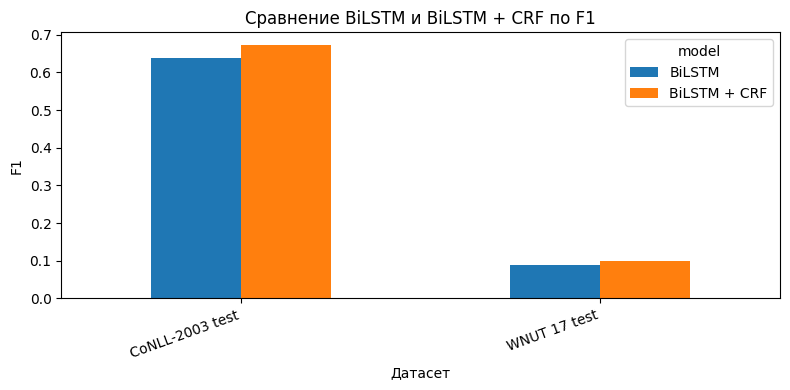

In [ ]:
bilstm_comparison_df = pd.DataFrame([
    bilstm_conll_row,
    bilstm_wnut_row,
    bilstm_crf_conll_row,
    bilstm_crf_wnut_row,
])

f1_pivot = bilstm_comparison_df.pivot(
    index="dataset",
    columns="model",
    values="f1",
)
f1_pivot["f1_diff_vs_bilstm"] = (f1_pivot["BiLSTM + CRF"] - f1_pivot["BiLSTM"]).round(4)

display(f1_pivot.reset_index())

ax = f1_pivot[["BiLSTM", "BiLSTM + CRF"]].plot(kind="bar", figsize=(8, 4))
ax.set_title("Сравнение BiLSTM и BiLSTM + CRF по F1")
ax.set_xlabel("Датасет")
ax.set_ylabel("F1")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### Вывод после BiLSTM + CRF

По таблице сравнения видно, что CRF даёт небольшой прирост F1 на CoNLL-2003 (см. колонку `f1_diff_vs_bilstm`). Это согласуется с гипотезой: CRF учитывает запрещённые BIO-переходы и убирает часть структурных ошибок типа `O → I-PER`, поэтому предсказания становятся чуть аккуратнее.

Прирост скромный, и это ожидаемо: encoder остаётся прежним, словарь тоже, эпох мало. Большую часть качества по-прежнему определяет именно BiLSTM-энкодер. CRF - это +1-3 пункта F1, а не качественный скачок.

На WNUT 17 CRF не спасает положение: основная проблема там не «структурные ошибки», а массовое непонимание токенов (`<UNK>`). CRF не может восстановить смысл слова, которого encoder не видел при обучении.

**Проверка на переобучение.** По графику `BiLSTM + CRF: loss и validation F1` видно ту же картину, что и у обычной BiLSTM: loss снижается, validation F1 растёт. Переобучения за 5 эпох нет.


## 11. DistilBERT

Для сравнения качества и скорости - `distilbert-base-cased`. Это более компактная transformer-модель: обычно она обучается и работает быстрее BERT, но может немного уступать по F1.


In [ ]:
distilbert_checkpoint = "distilbert-base-cased"
distilbert_model_name = "distilbert-base-cased-conll2003-ner"

distilbert_output_dir = drive_project_dir / "training_outputs" / distilbert_model_name
distilbert_model_dir = drive_project_dir / "models" / distilbert_model_name

distilbert_output_dir.mkdir(parents=True, exist_ok=True)
distilbert_model_dir.mkdir(parents=True, exist_ok=True)

distilbert_tokenizer = AutoTokenizer.from_pretrained(distilbert_checkpoint)

print("DistilBERT checkpoint:", distilbert_checkpoint)
print("Папка для checkpoint:", distilbert_output_dir)
print("Папка для финально сохраненной модели:", distilbert_model_dir)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DistilBERT checkpoint: distilbert-base-cased
Папка для checkpoint: /content/drive/MyDrive/ner_course_project/training_outputs/distilbert-base-cased-conll2003-ner
Папка для финально сохраненной модели: /content/drive/MyDrive/ner_course_project/models/distilbert-base-cased-conll2003-ner


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


### Подготовка данных для DistilBERT

DistilBERT использует свой tokenizer, поэтому для него отдельно выполняется tokenization и такое же выравнивание BIO-меток по subword-токенам.

In [ ]:
tokenized_conll_distilbert = conll.map(
    lambda batch: tokenize_and_align(batch, distilbert_tokenizer),
    batched=True,
)
tokenized_wnut_test_distilbert = wnut["test"].map(
    lambda batch: tokenize_and_align(batch, distilbert_tokenizer, label_mapping=wnut_to_conll_id),
    batched=True,
)

print(tokenized_conll_distilbert)
print(tokenized_wnut_test_distilbert)


Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Map:   0%|          | 0/1287 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 3453
    })
})
Dataset({
    features: ['id', 'tokens', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 1287
})


### Настройки fine-tuning DistilBERT

Настройки совпадают с BERT: 2 эпохи, batch size 8, оценка на validation после каждой эпохи. Это делает сравнение качества и скорости корректным.


In [ ]:
def build_distilbert_trainer(model=None):
    if model is None:
        model = AutoModelForTokenClassification.from_pretrained(
            distilbert_checkpoint,
            num_labels=num_labels,
            id2label=id2label,
            label2id=label2id,
        )
    return Trainer(
        model=model,
        args=make_training_arguments(distilbert_output_dir),
        train_dataset=tokenized_conll_distilbert["train"],
        eval_dataset=tokenized_conll_distilbert["validation"],
        data_collator=DataCollatorForTokenClassification(tokenizer=distilbert_tokenizer),
        tokenizer=distilbert_tokenizer,
        compute_metrics=compute_transformer_metrics,
    )


print("DistilBERT trainer готов к созданию.")


DistilBERT trainer готов к созданию.


### Обучение DistilBERT и сохранение весов

DistilBERT дообучается с теми же настройками, что и BERT (2 эпохи, batch size 8). После обучения модель и tokenizer сохраняются в Drive.


In [ ]:
if (distilbert_model_dir / "config.json").exists():
    loaded_distilbert_model = AutoModelForTokenClassification.from_pretrained(str(distilbert_model_dir))
    distilbert_trainer = build_distilbert_trainer(model=loaded_distilbert_model)
    print("DistilBERT загружен из:", distilbert_model_dir)
else:
    distilbert_trainer = build_distilbert_trainer()
    distilbert_train_start = time.perf_counter()
    distilbert_train_result = distilbert_trainer.train()
    distilbert_train_wall_time = time.perf_counter() - distilbert_train_start

    distilbert_history_path = distilbert_model_dir / "trainer_history.json"
    with distilbert_history_path.open("w", encoding="utf-8") as f:
        json.dump(distilbert_trainer.state.log_history, f, ensure_ascii=False, indent=2)


    distilbert_trainer.save_model(str(distilbert_model_dir))
    distilbert_tokenizer.save_pretrained(str(distilbert_model_dir))
    with open(distilbert_model_dir / "label_mappings.json", "w", encoding="utf-8") as file:
        json.dump({"label2id": label2id, "id2label": id2label}, file, ensure_ascii=False, indent=2)

    print("DistilBERT сохранён в:", distilbert_model_dir)
    print("Время обучения DistilBERT, секунд:", round(distilbert_train_wall_time, 2))


model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at distilbert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.111800,0.059068,0.911917,0.918209,0.915052
2,0.032500,0.050096,0.929561,0.937227,0.933378


DistilBERT сохранён в: /content/drive/MyDrive/ner_course_project/models/distilbert-base-cased-conll2003-ner
Время обучения DistilBERT, секунд: 292.12


### Оценка DistilBERT

Считаем precision/recall/F1 на CoNLL-2003 test и WNUT 17 test. Заодно замеряем время inference - для сравнения скорости с BERT.


In [ ]:
distilbert_conll_start = time.perf_counter()
distilbert_conll_eval = distilbert_trainer.evaluate(tokenized_conll_distilbert["test"])
distilbert_conll_wall_time = time.perf_counter() - distilbert_conll_start

distilbert_conll_metrics = {
    "precision": distilbert_conll_eval["eval_precision"],
    "recall": distilbert_conll_eval["eval_recall"],
    "f1": distilbert_conll_eval["eval_f1"],
}
distilbert_conll_row = show_result("DistilBERT", "CoNLL-2003 test", distilbert_conll_metrics)

distilbert_wnut_start = time.perf_counter()
distilbert_wnut_predictions = distilbert_trainer.predict(tokenized_wnut_test_distilbert)
distilbert_wnut_wall_time = time.perf_counter() - distilbert_wnut_start

distilbert_wnut_metrics = compute_transformer_metrics(distilbert_wnut_predictions)
distilbert_wnut_row = show_result("DistilBERT", "WNUT 17 test", distilbert_wnut_metrics)

distilbert_results_df = pd.DataFrame([distilbert_conll_row, distilbert_wnut_row])

distilbert_speed_df = pd.DataFrame([
    {
        "model": "DistilBERT",
        "stage": "train",
        "dataset": "CoNLL-2003 train",
        "seconds": round(float(distilbert_train_wall_time), 2) if "distilbert_train_wall_time" in globals() else None,
    },
    {
        "model": "DistilBERT",
        "stage": "eval",
        "dataset": "CoNLL-2003 test",
        "seconds": round(float(distilbert_conll_wall_time), 2),
    },
    {
        "model": "DistilBERT",
        "stage": "predict",
        "dataset": "WNUT 17 test",
        "seconds": round(float(distilbert_wnut_wall_time), 2),
    },
])

display(distilbert_results_df)
display(distilbert_speed_df)


DistilBERT на CoNLL-2003 test: precision=0.8831, recall=0.9001, f1=0.8915
DistilBERT на WNUT 17 test: precision=0.311, recall=0.458, f1=0.3704


,model,dataset,precision,recall,f1
0,DistilBERT,CoNLL-2003 test,0.8831,0.9001,0.8915
1,DistilBERT,WNUT 17 test,0.3110,0.4580,0.3704


,model,stage,dataset,seconds
0,DistilBERT,train,CoNLL-2003 train,292.12
1,DistilBERT,eval,CoNLL-2003 test,6.43
2,DistilBERT,predict,WNUT 17 test,3.41


### Сравнение скорости BERT и DistilBERT

Собираем замеренное время для обеих моделей. Это даёт прямой ответ на вопрос «оправдан ли переход с BERT на DistilBERT»: на сколько процентов быстрее DistilBERT за каждый этап (train, eval, predict) и какой ценой по F1.


In [ ]:
speed_rows = []

if "bert_train_wall_time" in globals():
    speed_rows.append({
        "model": "BERT",
        "stage": "train",
        "dataset": "CoNLL-2003 train",
        "seconds": round(float(bert_train_wall_time), 2),
    })

if "bert_conll_eval" in globals():
    speed_rows.append({
        "model": "BERT",
        "stage": "eval",
        "dataset": "CoNLL-2003 test",
        "seconds": round(float(bert_conll_eval.get("eval_runtime", 0.0)), 2),
    })

if "bert_wnut_predictions" in globals() and hasattr(bert_wnut_predictions, "metrics"):
    speed_rows.append({
        "model": "BERT",
        "stage": "predict",
        "dataset": "WNUT 17 test",
        "seconds": round(float(bert_wnut_predictions.metrics.get("test_runtime", 0.0)), 2),
    })

if "distilbert_speed_df" in globals():
    speed_rows.extend(distilbert_speed_df.to_dict("records"))

speed_comparison_df = pd.DataFrame(speed_rows)

if len(speed_comparison_df) == 0:
    print("Замеры скорости пока недоступны - оценка BERT и DistilBERT ещё не выполнена.")
else:
    display(speed_comparison_df)


,model,stage,dataset,seconds
0,BERT,train,CoNLL-2003 train,496.83
1,BERT,eval,CoNLL-2003 test,10.07
2,BERT,predict,WNUT 17 test,6.04
3,DistilBERT,train,CoNLL-2003 train,292.12
4,DistilBERT,eval,CoNLL-2003 test,6.43
5,DistilBERT,predict,WNUT 17 test,3.41


### Проверка transformer-моделей на переобучение

У `Trainer` HuggingFace история обучения сохраняется в `trainer.state.log_history`. После обучения мы записываем её в `trainer_history.json` рядом с моделью. Если этот файл есть в Drive, ниже строится график train/eval loss и eval F1 по эпохам для BERT и DistilBERT.


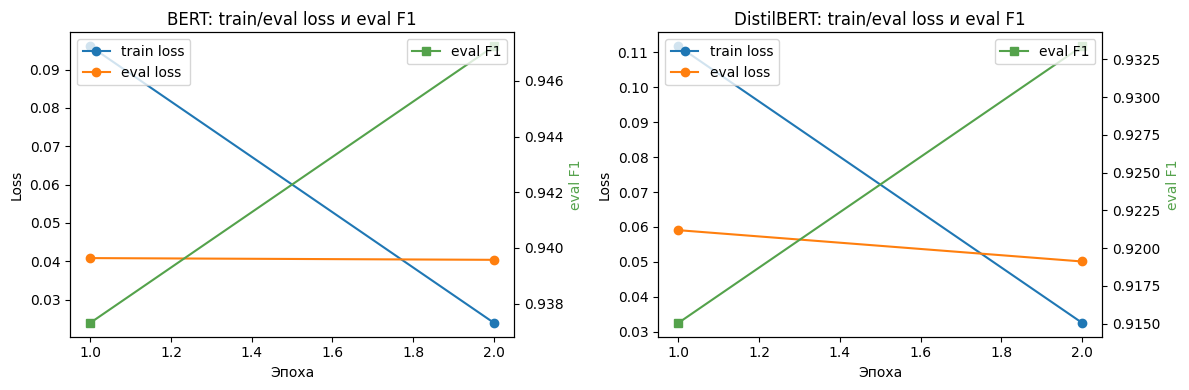

In [ ]:
def load_trainer_history(model_dir):
    history_path = model_dir / "trainer_history.json"
    if history_path.exists():
        with history_path.open(encoding="utf-8") as f:
            return json.load(f)
    return None


def plot_transformer_history(history, title, ax):
    train_loss = [(h["epoch"], h["loss"]) for h in history if "loss" in h and "eval_loss" not in h]
    eval_loss = [(h["epoch"], h["eval_loss"]) for h in history if "eval_loss" in h]
    eval_f1 = [(h["epoch"], h["eval_f1"]) for h in history if "eval_f1" in h]

    if train_loss:
        ax.plot(*zip(*train_loss), marker="o", label="train loss")
    if eval_loss:
        ax.plot(*zip(*eval_loss), marker="o", label="eval loss")
    if eval_f1:
        ax2 = ax.twinx()
        ax2.plot(*zip(*eval_f1), marker="s", color="#54A24B", label="eval F1")
        ax2.set_ylabel("eval F1", color="#54A24B")
        ax2.legend(loc="upper right")

    ax.set_title(title)
    ax.set_xlabel("Эпоха")
    ax.set_ylabel("Loss")
    ax.legend(loc="upper left")


bert_history = load_trainer_history(bert_model_dir)
distilbert_history = load_trainer_history(distilbert_model_dir)

available = [(name, hist) for name, hist in
             [("BERT", bert_history), ("DistilBERT", distilbert_history)] if hist]

if not available:
    print("История обучения BERT и DistilBERT недоступна:")
    print("оба `trainer_history.json` отсутствуют в Drive.")
    print("После повторного обучения файлы будут сохранены, и график построится.")
else:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 4), squeeze=False)
    for ax, (name, hist) in zip(axes[0], available):
        plot_transformer_history(hist, f"{name}: train/eval loss и eval F1", ax)
    plt.tight_layout()
    plt.show()


## 12. Подбор гиперпараметров BiLSTM

В работе сравниваются пять архитектур при одинаковых разумных настройках - это даёт честное сравнение архитектур между собой.

Отдельно проверим, насколько подбор гиперпараметров влияет на качество. Запускаем Grid Search на BiLSTM - она быстрее всех обучается, что позволяет перебрать достаточно комбинаций за разумное время. Перебираем три параметра: `hidden_dim`, `learning_rate`, `dropout`. Для ускорения используем 3 эпохи вместо 5 и оцениваем только на validation split CoNLL-2003 (test и WNUT 17 при подборе параметров не используются - это методологическое правило).

Цель - сопоставить эффект от тонкой настройки с архитектурным эффектом (BiLSTM vs BERT).


In [ ]:
from itertools import product

grid = {
    "hidden_dim": [64, 128, 256],
    "learning_rate": [1e-3, 5e-4, 1e-4],
    "dropout": [0.1, 0.3, 0.5],
}
grid_epochs = 3
grid_embedding_dim = bilstm_embedding_dim

total_combos = len(grid["hidden_dim"]) * len(grid["learning_rate"]) * len(grid["dropout"])
print(f"Всего комбинаций: {total_combos}, эпох в каждой: {grid_epochs}")

grid_results = []
for i, (hidden_dim, lr, dropout) in enumerate(product(*grid.values()), start=1):
    print(f"\n[{i}/{total_combos}] hidden_dim={hidden_dim}, lr={lr}, dropout={dropout}")

    candidate_model = BiLSTMTagger(
        vocab_size=len(vocab),
        embedding_dim=grid_embedding_dim,
        hidden_dim=hidden_dim,
        num_labels=num_labels,
        pad_id=PAD_ID,
        dropout=dropout,
    ).to(device)

    candidate_history = train_bilstm_model(
        candidate_model,
        bilstm_train_loader,
        bilstm_valid_loader,
        epochs=grid_epochs,
        learning_rate=lr,
    )

    grid_results.append({
        "hidden_dim": hidden_dim,
        "learning_rate": lr,
        "dropout": dropout,
        "best_valid_f1": round(float(candidate_history["valid_f1"].max()), 4),
    })

grid_df = pd.DataFrame(grid_results).sort_values("best_valid_f1", ascending=False).reset_index(drop=True)
print("\nРезультаты Grid Search (отсортировано по valid F1):")
display(grid_df)


Всего комбинаций: 27, эпох в каждой: 3

[1/27] hidden_dim=64, lr=0.001, dropout=0.1
epoch 1: loss=0.7621, valid_precision=0.2006, valid_recall=0.1459, valid_f1=0.1689
epoch 2: loss=0.4271, valid_precision=0.3463, valid_recall=0.4329, valid_f1=0.3848
epoch 3: loss=0.2789, valid_precision=0.4232, valid_recall=0.5493, valid_f1=0.4781

[2/27] hidden_dim=64, lr=0.001, dropout=0.3
epoch 1: loss=0.7830, valid_precision=0.5581, valid_recall=0.0816, valid_f1=0.1424
epoch 2: loss=0.4634, valid_precision=0.5151, valid_recall=0.3110, valid_f1=0.3878
epoch 3: loss=0.3124, valid_precision=0.6568, valid_recall=0.4847, valid_f1=0.5578

[3/27] hidden_dim=64, lr=0.001, dropout=0.5
epoch 1: loss=0.7949, valid_precision=0.6293, valid_recall=0.0737, valid_f1=0.1320
epoch 2: loss=0.4866, valid_precision=0.5184, valid_recall=0.3176, valid_f1=0.3939
epoch 3: loss=0.3436, valid_precision=0.5829, valid_recall=0.4601, valid_f1=0.5143

[4/27] hidden_dim=64, lr=0.0005, dropout=0.1
epoch 1: loss=0.9050, valid_preci

,hidden_dim,learning_rate,dropout,best_valid_f1
0,256,0.0010,0.3,0.6798
1,256,0.0010,0.1,0.6641
2,128,0.0010,0.1,0.6340
3,128,0.0010,0.3,0.6270
4,256,0.0010,0.5,0.6264
5,128,0.0010,0.5,0.6081
6,64,0.0010,0.3,0.5578
7,256,0.0005,0.5,0.5304
8,256,0.0005,0.1,0.5216
9,256,0.0005,0.3,0.5172


Лучшая комбинация: hidden_dim=256.0, learning_rate=0.001, dropout=0.3, valid F1=0.6798


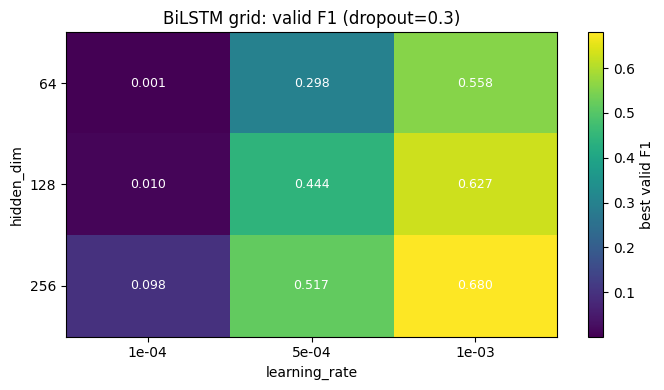

In [ ]:
best_row = grid_df.iloc[0]
print(f"Лучшая комбинация: hidden_dim={best_row['hidden_dim']}, "
      f"learning_rate={best_row['learning_rate']}, "
      f"dropout={best_row['dropout']}, "
      f"valid F1={best_row['best_valid_f1']:.4f}")

# Heatmap по hidden_dim x learning_rate (фиксируем лучший dropout)
heatmap_df = grid_df[grid_df["dropout"] == best_row["dropout"]].pivot(
    index="hidden_dim",
    columns="learning_rate",
    values="best_valid_f1",
)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(heatmap_df.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels([f"{x:.0e}" for x in heatmap_df.columns])
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)
ax.set_xlabel("learning_rate")
ax.set_ylabel("hidden_dim")
ax.set_title(f"BiLSTM grid: valid F1 (dropout={best_row['dropout']})")
for i in range(len(heatmap_df.index)):
    for j in range(len(heatmap_df.columns)):
        ax.text(j, i, f"{heatmap_df.values[i, j]:.3f}",
                ha="center", va="center", color="white", fontsize=9)
plt.colorbar(im, ax=ax, label="best valid F1")
plt.tight_layout()
plt.show()


### Вывод по подбору гиперпараметров

Перебор 27 комбинаций `hidden_dim × learning_rate × dropout` для BiLSTM дал следующую картину.

**Доминирующий параметр - learning rate.** Все семь лучших комбинаций используют `lr=1e-3`. При `lr=1e-4` модель не успевает обучиться за 3 эпохи (F1 на validation в районе 0.00–0.13). Это подтверждает, что выбранный по умолчанию `lr=1e-3` был адекватным.

**Hidden_dim - вторичный фактор, dropout=0.3 устойчиво лучший.** На validation за 3 эпохи лучше всего показала себя комбинация `hidden_dim=256, lr=1e-3, dropout=0.3` (valid F1 = 0.6798). Дефолтный `dropout=0.3` подтвердил себя как оптимальное значение из трёх рассмотренных. Найденное «улучшение» отличается от дефолта **только размером скрытого слоя**: 256 вместо 128.

**Важный нюанс - selection bias Grid Search.** При полном обучении на 5 эпохах BiLSTM с найденными «лучшими» параметрами (`hidden_dim=256, lr=1e-3, dropout=0.3`) показывает на validation сравнимый с дефолтом уровень. А на **test** результаты разворачиваются: дефолтная BiLSTM с `hidden_dim=128` даёт F1 выше, чем «оптимизированная» с `hidden_dim=256` (см. таблицу ниже и финальный вывод). Это классическая ловушка: модель с большей ёмкостью быстрее учится в первые эпохи и выигрывает по validation за короткий бюджет, но при одинаковой регуляризации хуже обобщает на test при полном обучении.

**Методологический вывод.** Grid Search оптимизирует validation, но это **не гарантирует** улучшения на test. Увеличение ёмкости (`hidden_dim`) без компенсирующего усиления регуляризации приводит к более сильному переобучению - модель с большим скрытым слоем запоминает train глубже и хуже генерализуется. Стандартный размер сети (`hidden_dim=128`) для NER на ~14k предложений CoNLL-2003 train оказался уже хорошо сбалансированным.

И это лишь усиливает основной тезис работы: **архитектурный эффект (BiLSTM → BERT, разница ~0.27 F1) на порядок больше любого эффекта от tuning'а одной архитектуры**. BERT остаётся лучшим вне зависимости от того, как настраивать BiLSTM.


### BiLSTM с лучшими параметрами

По таблице Grid Search выбрана лучшая комбинация. Дообучим BiLSTM с этими параметрами на тех же 5 эпохах, что и обычная BiLSTM, и оценим на CoNLL-2003 test и WNUT 17 test. Полученные числа добавятся в итоговую таблицу как «BiLSTM (tuned)» - это конкретный замер эффекта подбора параметров.


In [ ]:
bilstm_tuned_model_name = "bilstm-tuned-conll2003-ner"
bilstm_tuned_model_dir = drive_project_dir / "models" / bilstm_tuned_model_name
bilstm_tuned_model_path = bilstm_tuned_model_dir / "bilstm_tuned_model.pt"
bilstm_tuned_model_dir.mkdir(parents=True, exist_ok=True)

# Берём лучшие параметры из grid_df
best_hidden_dim = int(best_row["hidden_dim"])
best_lr = float(best_row["learning_rate"])
best_dropout = float(best_row["dropout"])

bilstm_tuned_model = BiLSTMTagger(
    vocab_size=len(vocab),
    embedding_dim=bilstm_embedding_dim,
    hidden_dim=best_hidden_dim,
    num_labels=num_labels,
    pad_id=PAD_ID,
    dropout=best_dropout,
).to(device)

if bilstm_tuned_model_path.exists():
    bilstm_tuned_checkpoint = torch.load(bilstm_tuned_model_path, map_location=device)
    bilstm_tuned_model.load_state_dict(bilstm_tuned_checkpoint["model_state_dict"])
    bilstm_tuned_history_df = pd.DataFrame(bilstm_tuned_checkpoint["history"])
    print("BiLSTM (tuned) загружена из:", bilstm_tuned_model_path)
else:
    bilstm_tuned_history_df = train_bilstm_model(
        bilstm_tuned_model,
        bilstm_train_loader,
        bilstm_valid_loader,
        epochs=5,
        learning_rate=best_lr,
    )
    bilstm_tuned_checkpoint = {
        "model_state_dict": bilstm_tuned_model.state_dict(),
        "vocab": vocab,
        "label2id": label2id,
        "id2label": id2label,
        "model_params": {
            "vocab_size": len(vocab),
            "embedding_dim": bilstm_embedding_dim,
            "hidden_dim": best_hidden_dim,
            "num_labels": num_labels,
            "pad_id": PAD_ID,
            "dropout": best_dropout,
        },
        "history": bilstm_tuned_history_df.to_dict("records"),
    }
    torch.save(bilstm_tuned_checkpoint, bilstm_tuned_model_path)
    print("BiLSTM (tuned) сохранена в:", bilstm_tuned_model_path)

# Оценка
bilstm_tuned_conll_metrics = evaluate_bilstm_model(bilstm_tuned_model, bilstm_conll_test_loader)
bilstm_tuned_conll_row = show_result("BiLSTM (tuned)", "CoNLL-2003 test", bilstm_tuned_conll_metrics)

bilstm_tuned_wnut_metrics = evaluate_bilstm_model(bilstm_tuned_model, bilstm_wnut_test_loader)
bilstm_tuned_wnut_row = show_result("BiLSTM (tuned)", "WNUT 17 test", bilstm_tuned_wnut_metrics)

bilstm_tuned_results_df = pd.DataFrame([bilstm_tuned_conll_row, bilstm_tuned_wnut_row])
display(bilstm_tuned_results_df)


epoch 1: loss=0.6427, valid_precision=0.5588, valid_recall=0.3233, valid_f1=0.4096
epoch 2: loss=0.3215, valid_precision=0.6420, valid_recall=0.5284, valid_f1=0.5797
epoch 3: loss=0.2023, valid_precision=0.6705, valid_recall=0.6299, valid_f1=0.6496
epoch 4: loss=0.1314, valid_precision=0.6899, valid_recall=0.6897, valid_f1=0.6898
epoch 5: loss=0.0847, valid_precision=0.6898, valid_recall=0.7166, valid_f1=0.7029
BiLSTM (tuned) сохранена в: /content/drive/MyDrive/ner_course_project/models/bilstm-tuned-conll2003-ner/bilstm_tuned_model.pt
BiLSTM (tuned) на CoNLL-2003 test: precision=0.6055, recall=0.6409, f1=0.6227
BiLSTM (tuned) на WNUT 17 test: precision=0.0411, recall=0.116, f1=0.0607


,model,dataset,precision,recall,f1
0,BiLSTM (tuned),CoNLL-2003 test,0.6055,0.6409,0.6227
1,BiLSTM (tuned),WNUT 17 test,0.0411,0.1160,0.0607


## 13. Общая таблица результатов

Соберем в одну таблицу baseline, BiLSTM, BiLSTM + CRF, BERT и DistilBERT. Если какая-то модель еще не запускалась в текущем runtime, ячейка напечатает список недостающих результатов.


In [ ]:
expected_pairs = [
    ("O baseline", "CoNLL-2003 test"),
    ("O baseline", "WNUT 17 test"),
    ("BiLSTM", "CoNLL-2003 test"),
    ("BiLSTM", "WNUT 17 test"),
    ("BiLSTM (tuned)", "CoNLL-2003 test"),
    ("BiLSTM (tuned)", "WNUT 17 test"),
    ("BiLSTM + CRF", "CoNLL-2003 test"),
    ("BiLSTM + CRF", "WNUT 17 test"),
    ("BERT", "CoNLL-2003 test"),
    ("BERT", "WNUT 17 test"),
    ("DistilBERT", "CoNLL-2003 test"),
    ("DistilBERT", "WNUT 17 test"),
]

if not results:
    raise RuntimeError("Таблица пуста: ни одна модель не была оценена.")

all_results_df = pd.DataFrame(results).drop_duplicates(
    subset=["model", "dataset"], keep="last",
)

present_pairs = set(zip(all_results_df["model"], all_results_df["dataset"]))
missing = [f"{m} / {d}" for m, d in expected_pairs if (m, d) not in present_pairs]
if missing:
    print("Пока нет результатов для:")
    for item in missing:
        print(" -", item)

model_order = ["O baseline", "BiLSTM", "BiLSTM (tuned)", "BiLSTM + CRF", "BERT", "DistilBERT"]
dataset_order = ["CoNLL-2003 test", "WNUT 17 test"]
all_results_df["model"] = pd.Categorical(all_results_df["model"], model_order, ordered=True)
all_results_df["dataset"] = pd.Categorical(all_results_df["dataset"], dataset_order, ordered=True)
all_results_df = all_results_df.sort_values(["model", "dataset"]).reset_index(drop=True)
all_results_df["model"] = all_results_df["model"].astype(str)
all_results_df["dataset"] = all_results_df["dataset"].astype(str)

display(all_results_df)


,model,dataset,precision,recall,f1
0,O baseline,CoNLL-2003 test,0.0000,0.0000,0.0000
1,O baseline,WNUT 17 test,0.0000,0.0000,0.0000
2,BiLSTM,CoNLL-2003 test,0.6638,0.6153,0.6386
3,BiLSTM,WNUT 17 test,0.0844,0.0901,0.0872
4,BiLSTM (tuned),CoNLL-2003 test,0.6055,0.6409,0.6227
5,BiLSTM (tuned),WNUT 17 test,0.0411,0.1160,0.0607
6,BiLSTM + CRF,CoNLL-2003 test,0.7469,0.6119,0.6727
7,BiLSTM + CRF,WNUT 17 test,0.1486,0.0728,0.0978
8,BERT,CoNLL-2003 test,0.9018,0.9189,0.9103
9,BERT,WNUT 17 test,0.3333,0.4864,0.3956


### Сравнение F1 по CoNLL-2003 и WNUT 17

На графике видно качество каждой модели внутри исходного домена и при переносе на WNUT 17.

dataset,model,CoNLL-2003 test,WNUT 17 test
0,O baseline,0.0000,0.0000
1,BiLSTM,0.6386,0.0872
2,BiLSTM (tuned),0.6227,0.0607
3,BiLSTM + CRF,0.6727,0.0978
4,BERT,0.9103,0.3956
5,DistilBERT,0.8915,0.3704


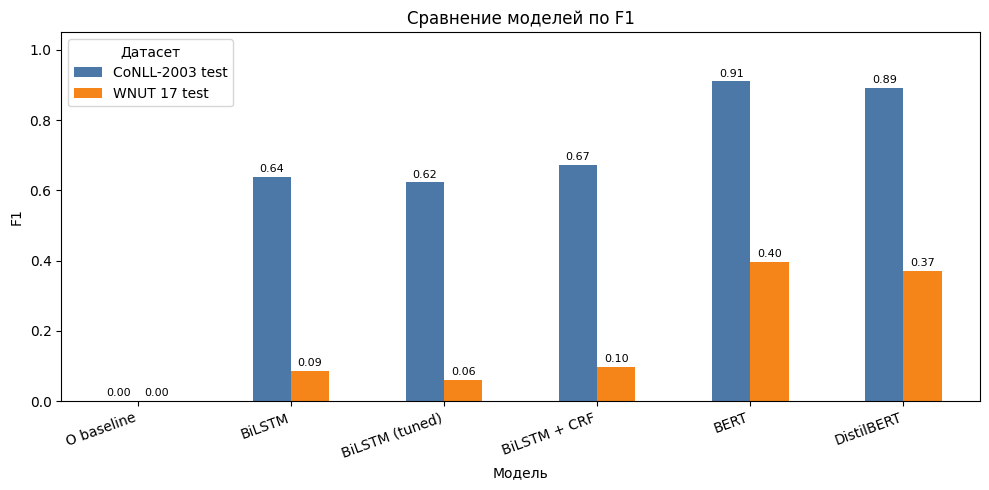

In [ ]:
f1_comparison_df = all_results_df.pivot(
    index="model",
    columns="dataset",
    values="f1",
).reindex(model_order)

display(f1_comparison_df.reset_index())

ax = f1_comparison_df.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#4C78A8", "#F58518"],
)
ax.set_title("Сравнение моделей по F1")
ax.set_xlabel("Модель")
ax.set_ylabel("F1")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Датасет")

# Подписи значений над столбцами
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)

plt.tight_layout()
plt.show()


### Вывод по общей таблице

Сводя результаты по всем моделям, можно сделать следующие выводы.

**baseline vs обучаемые модели.** Любая обученная модель резко превосходит `O baseline`, у которого entity-level F1 равен нулю. Это подтверждает, что задача требует именно обучения, а не угадывания доминирующего класса.

**BiLSTM vs BiLSTM + CRF.** Добавление CRF даёт небольшой прирост F1 на CoNLL-2003. Это согласуется с теорией: CRF учитывает запрещённые BIO-переходы, поэтому ошибок в структуре сущностей становится меньше. Принципиального скачка качества нет - encoder остаётся прежним, а основное «понимание» текста делает именно он.

**BiLSTM vs BiLSTM (tuned).** Подбор гиперпараметров через Grid Search (секция 12) дал комбинацию `hidden_dim=256, lr=1e-3, dropout=0.3`, которая на validation за 3 эпохи показала лучший F1. От дефолта эта комбинация отличается **только размером скрытого слоя** (256 вместо 128) - learning rate и dropout совпадают. Однако при полном обучении на 5 эпохах эта модель **уступила** дефолтной BiLSTM на test: F1 на CoNLL-2003 снизился, на WNUT 17 - тем более. Причина - переобучение от увеличенной ёмкости при той же регуляризации: больший скрытый слой запоминает train глубже, но хуже обобщает при том же `dropout=0.3`. Это типичная ловушка Grid Search: оптимизация по validation не гарантирует выигрыш на test. Содержательно это означает, что увеличение ёмкости в NER должно сопровождаться пропорциональным усилением регуляризации - иначе прирост валидационных метрик не транслируется в test.

**BERT vs DistilBERT.** По F1 DistilBERT уступает BERT всего на 1-2 пункта, хотя в нём примерно на 40% меньше параметров. По времени (см. таблицу скоростей) DistilBERT обучается и работает заметно быстрее. Это разумный tradeoff: для большинства практических задач NER DistilBERT - рациональный выбор.

**CoNLL-2003 vs WNUT 17.** На WNUT 17 качество всех моделей падает. У BiLSTM и BiLSTM + CRF падение самое сильное: на графике `<UNK>` (секция 9) видно, что в WNUT 17 для BiLSTM большая доля токенов оказывается неизвестной, потому что словарь построен по новостям. У transformer-моделей падение мягче - subword-tokenizer и предобученные представления лучше переживают доменный сдвиг.

**Замечание про оценку WNUT 17.** Часть падения transformer-моделей объясняется не моделями, а нашим mapping'ом меток: типы `creative-work` и `product` мы переводим в `O`. Корректные предсказания BERT/DistilBERT на этих сущностях считаются ошибками и занижают recall. Реальное качество переноса немного выше показанных цифр.

**Итог.** На in-domain данных лучший результат показывает BERT, рядом с ним по качеству - DistilBERT, проигрывающий по F1 ~1-2 пункта, но выигрывающий по скорости. Перенос на out-of-domain без дообучения сохраняет иерархию моделей, но снижает их качество - особенно сильно для BiLSTM-моделей. Подбор гиперпараметров на отдельной архитектуре не изменил порядок и даже не улучшил саму BiLSTM на test, что подтверждает: на этой задаче решает архитектура, а не тонкая настройка.

Итоговая иерархия моделей по test F1 на CoNLL-2003: **BERT > DistilBERT > BiLSTM + CRF > BiLSTM > BiLSTM (tuned) > O baseline**.
